# Face Mask Detection - EDA Report

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# styling
sns.set(style="whitegrid")

## Extract Dataset

In [14]:
!pip install kaggle

In [15]:
import json

kaggle_key = {
    "username": "salmaazoz",
    "key": "KGAT_4317d3f4cb9226d2bc3d43c050431d03"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_key, f)

In [16]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [19]:
!kaggle datasets download -d ashishjangra27/face-mask-12k-images-dataset

Dataset URL: https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset
License(s): CC0-1.0
100% 330M/330M [00:06<00:00, 55.5MB/s]



In [20]:
import zipfile

with zipfile.ZipFile("face-mask-12k-images-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [21]:
import os

print(os.listdir("/content/dataset"))

['Face Mask Dataset', 'data']


In [25]:
import os

base_path = "/content/dataset/Face Mask Dataset"

print(os.listdir(base_path))

['Train', 'Validation', 'Test']


In [26]:
train_path = "/content/dataset/Face Mask Dataset/Train"

print(os.listdir(train_path))

['WithoutMask', 'WithMask']


## 1. Sample Images per Class

This visualization shows random samples from each class (WithMask vs WithoutMask).

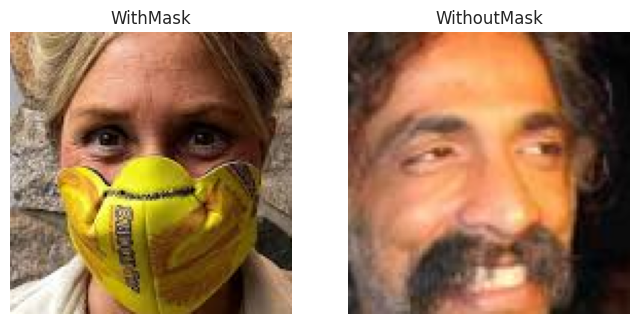

In [29]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = ["WithMask", "WithoutMask"]
train_path = "/content/dataset/Face Mask Dataset/Train"

plt.figure(figsize=(8,4))

for i, cls in enumerate(classes):
    img_path = os.path.join(train_path, cls, os.listdir(os.path.join(train_path, cls))[0])
    img = Image.open(img_path)

    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

Insight

The dataset contains two classes: WithMask and WithoutMask.
The images clearly show facial differences, where masked faces cover the nose and mouth area,
making it suitable for binary classification using deep learning models.

## 2. Class Distribution

This plot shows the number of images in each class (WithMask vs WithoutMask).
It helps check if the dataset is balanced or imbalanced.

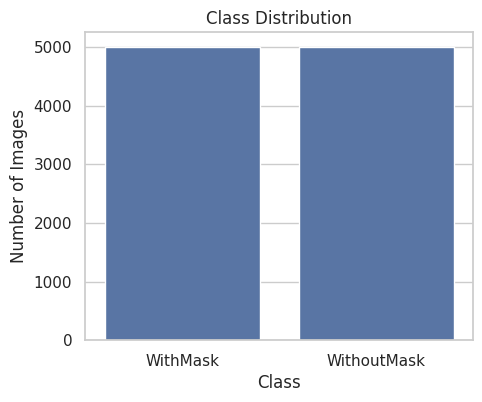

In [30]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

train_path = "/content/dataset/Face Mask Dataset/Train"
classes = ["WithMask", "WithoutMask"]

counts = []

for cls in classes:
    path = os.path.join(train_path, cls)
    counts.append(len(os.listdir(path)))

plt.figure(figsize=(5,4))
sns.barplot(x=classes, y=counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

Insight

The dataset is well balanced between WithMask and WithoutMask classes,
which is beneficial for training a deep learning model without bias toward any class.

## 3. Image Size Distribution

This plot shows the distribution of image widths and heights in the dataset.
It helps understand if images need resizing before training.

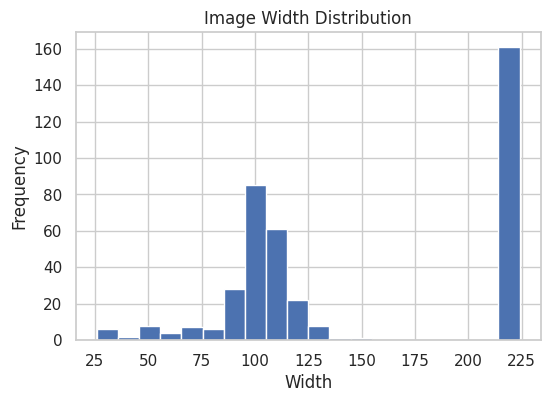

In [31]:
import os
import cv2
import matplotlib.pyplot as plt

train_path = "/content/dataset/Face Mask Dataset/Train"
classes = ["WithMask", "WithoutMask"]

widths = []
heights = []

for cls in classes:
    path = os.path.join(train_path, cls)

    for img_name in os.listdir(path)[:200]:  # sample 200 images
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)

        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(6,4))
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

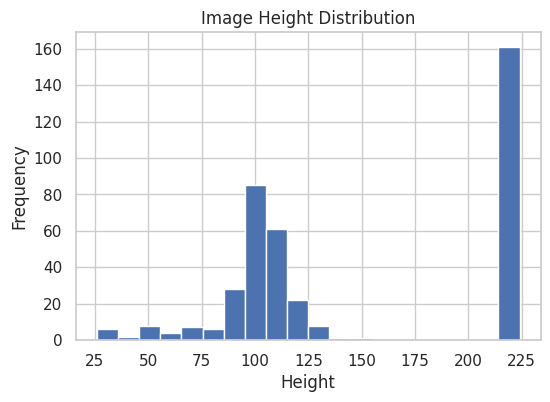

In [32]:
plt.figure(figsize=(6,4))
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

 Insight

Most images in the dataset have similar width and height ranges,
which indicates that resizing during preprocessing will be straightforward
and will not cause significant distortion.

## 4. Pixel Intensity Distribution

This plot shows the distribution of pixel values in grayscale images.
It helps understand brightness and contrast levels in the dataset.

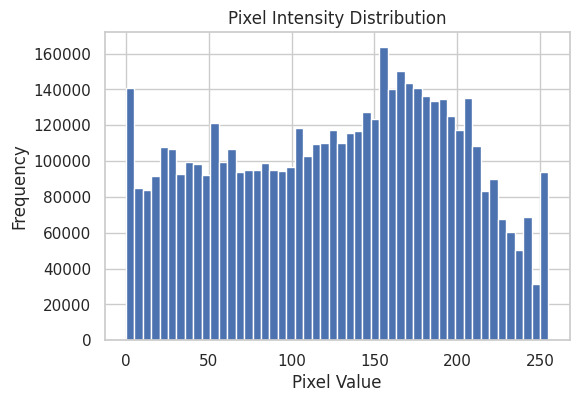

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

train_path = "/content/dataset/Face Mask Dataset/Train"
classes = ["WithMask", "WithoutMask"]

pixels = []

for cls in classes:
    path = os.path.join(train_path, cls)

    for img_name in os.listdir(path)[:100]:  # sample 100 images
        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        pixels.extend(img.flatten())

plt.figure(figsize=(6,4))
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

 Insight

The pixel intensity distribution shows a wide range of values,
indicating good contrast and variability in lighting conditions,
which helps improve model generalization.

## 5. RGB Channel Distribution

This plot shows the distribution of Red, Green, and Blue channels.
It helps understand color composition in the dataset images.

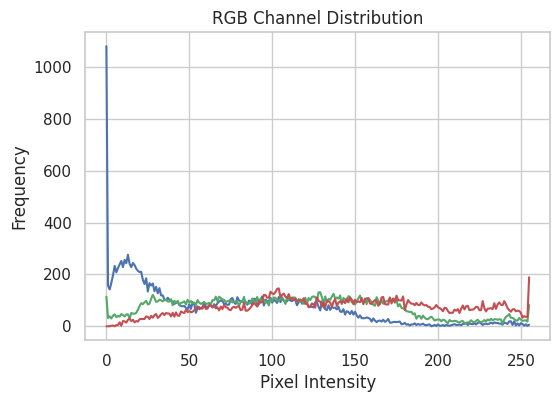

In [34]:
import cv2
import matplotlib.pyplot as plt
import os

train_path = "/content/dataset/Face Mask Dataset/Train"
classes = ["WithMask", "WithoutMask"]

#one photo as example
sample_class = classes[0]
img_path = os.path.join(train_path, sample_class, os.listdir(os.path.join(train_path, sample_class))[0])

img = cv2.imread(img_path)

colors = ('b', 'g', 'r')

plt.figure(figsize=(6,4))

for i, color in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0,256])
    plt.plot(hist, color=color)

plt.title("RGB Channel Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

 Insight

The RGB channels show different intensity distributions,
indicating variations in lighting and color composition across images.
This supports robust feature learning for the model.

## 6. Face Diversity (Random Image Grid)

This visualization shows random samples from the dataset to analyze variations in pose, lighting, and mask types.

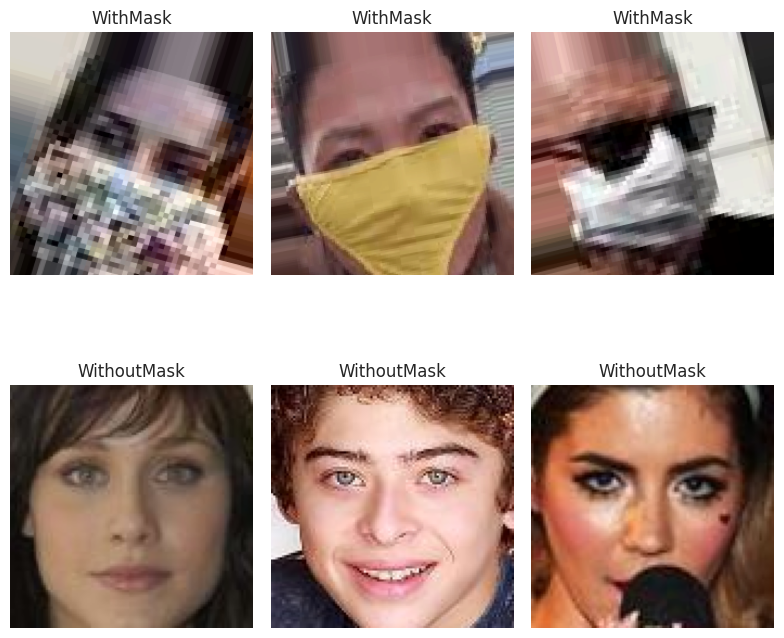

In [35]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

train_path = "/content/dataset/Face Mask Dataset/Train"
classes = ["WithMask", "WithoutMask"]

plt.figure(figsize=(8,8))

img_count = 1

for cls in classes:
    path = os.path.join(train_path, cls)
    images = os.listdir(path)

    for i in range(3):  # 3 images per class
        img_name = random.choice(images)
        img_path = os.path.join(path, img_name)

        img = Image.open(img_path)

        plt.subplot(2,3,img_count)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

        img_count += 1

plt.tight_layout()
plt.show()

 Insight

The dataset contains diverse facial images with variations in lighting, pose, and mask styles.
This diversity improves model robustness and generalization.

## 7. Average Pixel Intensity per Class

This plot compares the average pixel brightness between WithMask and WithoutMask classes.
It helps identify differences in image lighting and exposure.

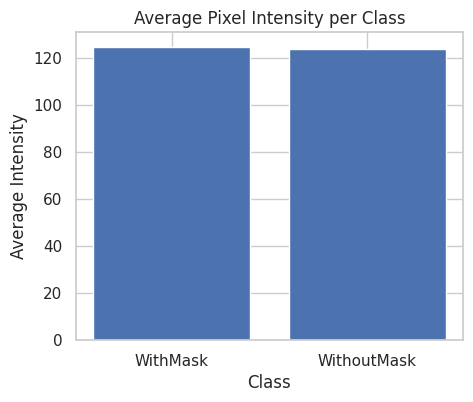

In [36]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

train_path = "/content/dataset/Face Mask Dataset/Train"
classes = ["WithMask", "WithoutMask"]

avg_intensities = []

for cls in classes:
    path = os.path.join(train_path, cls)
    values = []

    for img_name in os.listdir(path)[:100]:
        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        values.append(np.mean(img))

    avg_intensities.append(np.mean(values))

plt.figure(figsize=(5,4))
plt.bar(classes, avg_intensities)

plt.title("Average Pixel Intensity per Class")
plt.xlabel("Class")
plt.ylabel("Average Intensity")

plt.show()

Insight

Both classes show similar average pixel intensities,
indicating consistent lighting conditions across the dataset,
which reduces bias caused by brightness differences.

## 8. Image Shape (Aspect Ratio) Analysis

This plot shows the distribution of image dimensions (width vs height).
It helps understand whether images need resizing or normalization.

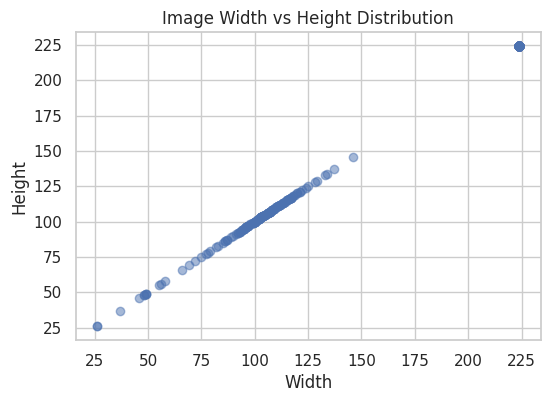

In [37]:
import os
import cv2
import matplotlib.pyplot as plt

train_path = "/content/dataset/Face Mask Dataset/Train"
classes = ["WithMask", "WithoutMask"]

widths = []
heights = []

for cls in classes:
    path = os.path.join(train_path, cls)

    for img_name in os.listdir(path)[:150]:
        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path)

        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(6,4))
plt.scatter(widths, heights, alpha=0.5)

plt.title("Image Width vs Height Distribution")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

Insight

The scatter plot shows that most images have similar width and height ranges,
indicating consistent image shapes across the dataset.
This simplifies preprocessing steps such as resizing.

#  EDA Summary & Conclusion

This section summarizes the key findings from the exploratory data analysis of the Face Mask dataset.

## Key Findings:

- The dataset contains two main classes: WithMask and WithoutMask.
- The dataset is balanced, which prevents model bias.
- Image sizes are relatively consistent, making preprocessing easier.
- Pixel intensity distribution shows good contrast across images.
- RGB channels indicate varied lighting conditions.
- Face images show diversity in pose, mask types, and lighting.

## Conclusion:

The dataset is clean, well-structured, and suitable for training a deep learning model for face mask detection.
The visual analysis confirms that the data is balanced and rich in variation, which supports good model generalization.